In [2]:
import json
import time
import requests
from pathlib import Path
from datetime import datetime, timezone
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import sseclient

from water_class import ThamesPredictor

# from bot_template import BaseBot, OrderBook, Order, OrderRequest, OrderResponse, Trade, Side, Product

In [3]:
TP = ThamesPredictor()

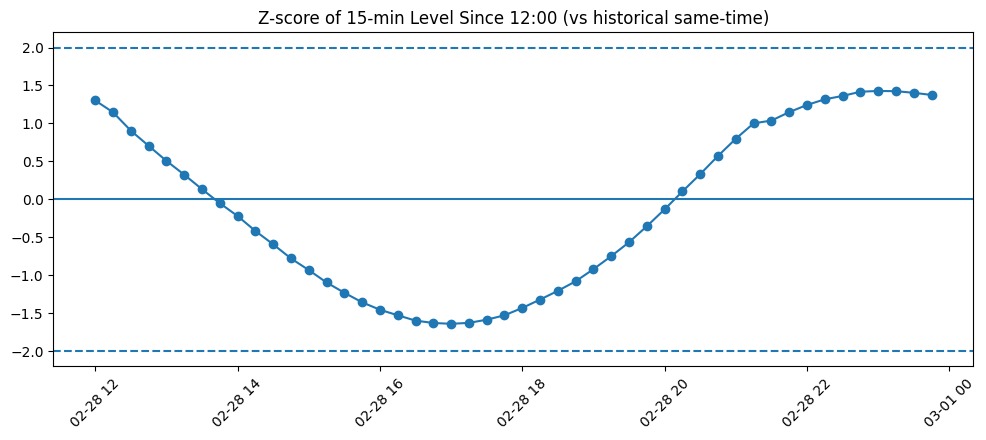

                     time  level   tod     mean      std   zscore
2026-02-28 21:30:00+00:00  1.660 21:30 0.011400 1.587895 1.038230
2026-02-28 21:45:00+00:00  1.864 21:45 0.022067 1.602879 1.149141
2026-02-28 22:00:00+00:00  2.077 22:00 0.048067 1.630983 1.243994
2026-02-28 22:15:00+00:00  2.258 22:15 0.062667 1.665539 1.318092
2026-02-28 22:30:00+00:00  2.432 22:30 0.096533 1.713997 1.362585
2026-02-28 22:45:00+00:00  2.614 22:45 0.133533 1.749465 1.417843
2026-02-28 23:00:00+00:00  2.744 23:00 0.183400 1.793010 1.428101
2026-02-28 23:15:00+00:00  2.857 23:15 0.225400 1.846836 1.424924
2026-02-28 23:30:00+00:00  2.947 23:30 0.271200 1.906309 1.403655
2026-02-28 23:45:00+00:00  2.996 23:45 0.329667 1.938684 1.375332


c:\Users\arsen\ICAlgothon26\water_class.py:80: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return 100.0 * zt["strangle"].rolling(window).sum()


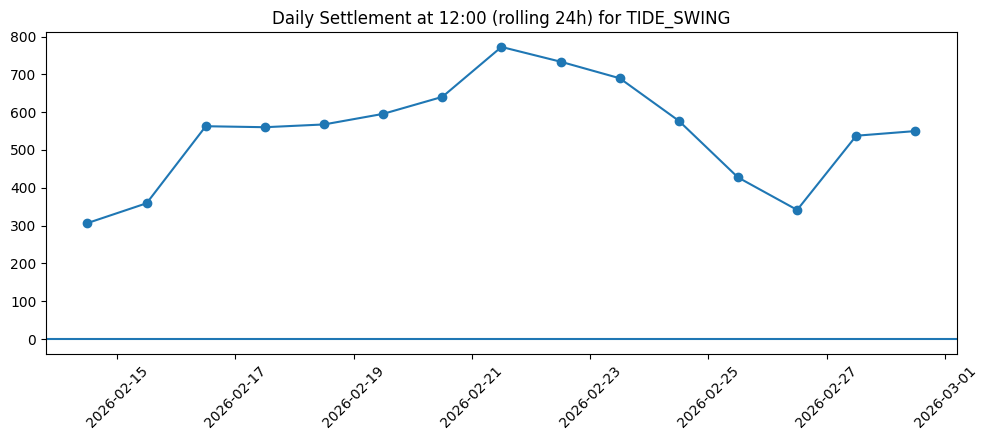

                     time  settlement       date
2026-02-19 12:00:00+00:00       595.5 2026-02-19
2026-02-20 12:00:00+00:00       640.4 2026-02-20
2026-02-21 12:00:00+00:00       772.4 2026-02-21
2026-02-22 12:00:00+00:00       733.4 2026-02-22
2026-02-23 12:00:00+00:00       689.6 2026-02-23
2026-02-24 12:00:00+00:00       577.0 2026-02-24
2026-02-25 12:00:00+00:00       427.4 2026-02-25
2026-02-26 12:00:00+00:00       341.5 2026-02-26
2026-02-27 12:00:00+00:00       537.7 2026-02-27
2026-02-28 12:00:00+00:00       550.0 2026-02-28


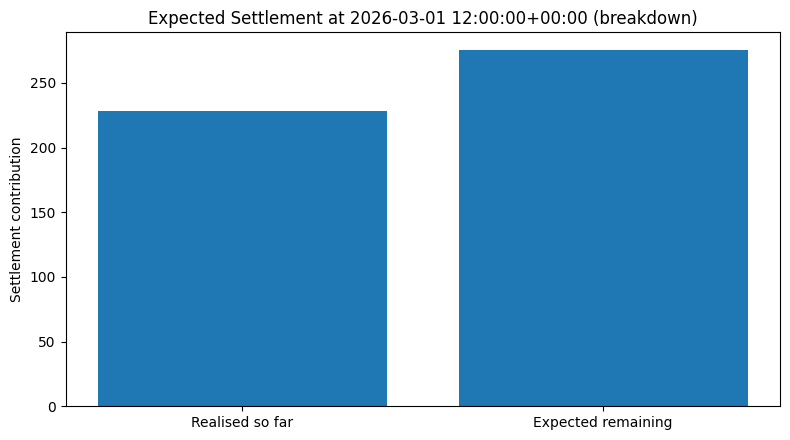

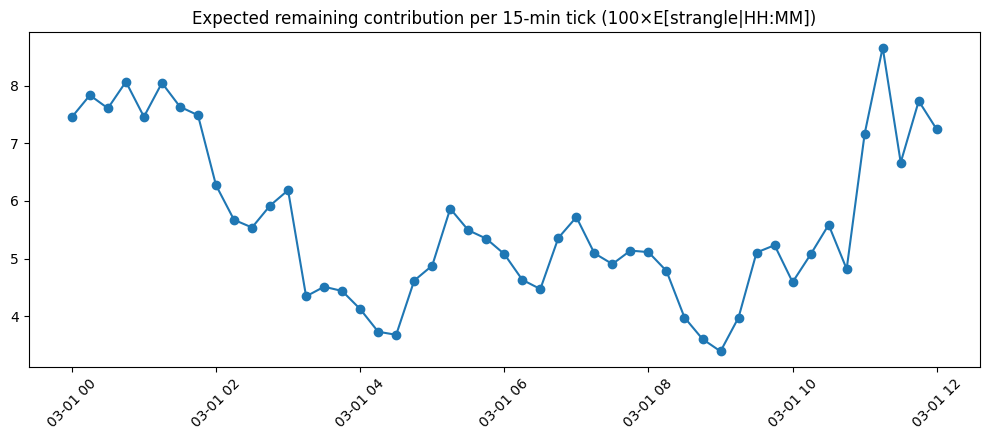

{'now': Timestamp('2026-02-28 23:45:00+0000', tz='Europe/London'), 'next_noon': Timestamp('2026-03-01 12:00:00+0000', tz='Europe/London'), 'realised_component': 228.70000000000007, 'expected_remaining_component': 275.3733333333334, 'expected_settlement': 504.07333333333344, 'history_coverage': 1.0}


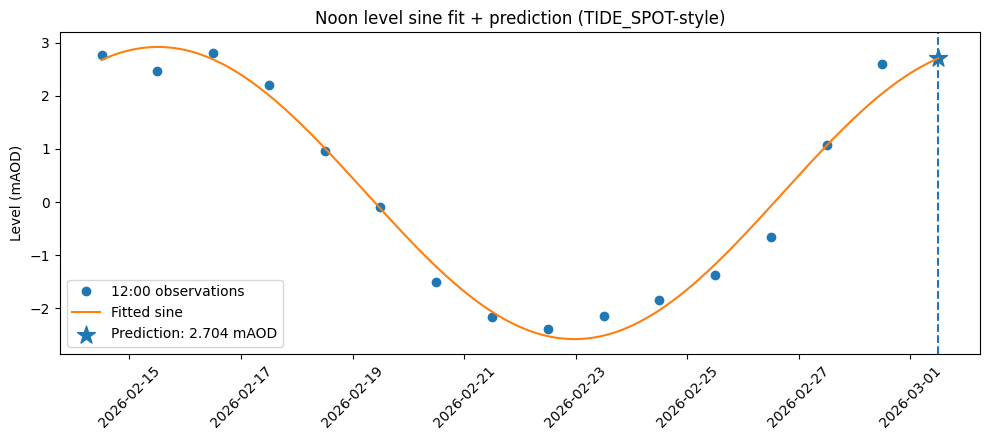

{'A': 2.7476636730387636, 'period_hours': 358.53031900254337, 'phase_hours': -65.41285254001917, 'offset': 0.17141545577790557}
Predicted noon level: 2.7035799033342602
Predicted |level| mm: 2703.57990333426


In [5]:
tp = ThamesPredictor()

zz = tp.get_thames(limit=1450)

# 1) Plot z-scores for today's level since 12:00
zdf = tp.plot_zscore_today_since_noon(zz)
print(zdf.tail(10).to_string(index=False))

# 2) Plot historical noon settlements
daily = tp.plot_daily_noon_settlements(zz, last_n=20)
print(daily.tail(10).to_string(index=False))

# 3) Plot expected settlement breakdown for next noon
exp = tp.plot_expected_settlement_breakdown(zz)
print({k: exp[k] for k in ["now", "next_noon", "realised_component", "expected_remaining_component", "expected_settlement", "history_coverage"]})

# 4) Plot noon sine fit + prediction
fit = tp.plot_noon_sine_fit_and_prediction(zz)
if fit.get("ok", False):
    print(fit["params"])
    print("Predicted noon level:", fit["predicted_level"])
    print("Predicted |level| mm:", fit["predicted_abs_mm"])

In [7]:
daily

,time,settlement,date
0,2026-02-14 12:00:00+00:00,306.8,2026-02-14
1,2026-02-15 12:00:00+00:00,359.2,2026-02-15
2,2026-02-16 12:00:00+00:00,562.8,2026-02-16
3,2026-02-17 12:00:00+00:00,560.2,2026-02-17
4,2026-02-18 12:00:00+00:00,567.5,2026-02-18
5,2026-02-19 12:00:00+00:00,595.5,2026-02-19
6,2026-02-20 12:00:00+00:00,640.4,2026-02-20
7,2026-02-21 12:00:00+00:00,772.4,2026-02-21
8,2026-02-22 12:00:00+00:00,733.4,2026-02-22
9,2026-02-23 12:00:00+00:00,689.6,2026-02-23


In [6]:
zz

,time,level
0,2026-02-13 21:30:00+00:00,2.260
1,2026-02-13 21:45:00+00:00,2.479
2,2026-02-13 22:00:00+00:00,2.683
3,2026-02-13 22:15:00+00:00,2.823
4,2026-02-13 22:30:00+00:00,2.963
...,...,...
1445,2026-02-28 22:45:00+00:00,2.614
1446,2026-02-28 23:00:00+00:00,2.744
1447,2026-02-28 23:15:00+00:00,2.857
1448,2026-02-28 23:30:00+00:00,2.947
